In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
!pip install seaborn


# coronavirus CDR

In [5]:
data = pd.read_csv('corona.tsv', sep='\t')

In [6]:
data

,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1
0,9cci,B,TFGTYYDNTEDWFFDF,YGGDSD,GYSFSSF
1,9ccj,H,LPLGERIDY,YYSGT,GGSINTNMY
2,9bj2,H,HNGDPYDFWSGYNTWAGGLDV,IPFLDV,GVIFSRN
3,8z6r,E,QGDLGDWILLGY,YPGDSD,GYTFSYY
4,8z6s,E,QGDLGDWILLGY,YPGDSD,GYTFSYY
...,...,...,...,...,...
754,7tly,A,DYTRGAWFGESLIGGFDN,STYNGN,GYPFTSY
755,7chp,H,DLQEHGMDV,YSGGS,GFTVSSN
756,7n4i,H,LLYYSDSSPLDS,YPGDSD,GYSFISY
757,7l7d,H,PYCSSISCNDGFDI,VIGSGN,GFTFMSS


In [17]:
for i in range(1,4):
    data[f'len_H{i}'] = data[f'CDR_H{i}'].apply(lambda x: len(x) if isinstance(x, str) else 0)

In [23]:
data

,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,len_H3,len_H1,len_H2
0,9cci,B,TFGTYYDNTEDWFFDF,YGGDSD,GYSFSSF,16,7,6
1,9ccj,H,LPLGERIDY,YYSGT,GGSINTNMY,9,9,5
2,9bj2,H,HNGDPYDFWSGYNTWAGGLDV,IPFLDV,GVIFSRN,21,7,6
3,8z6r,E,QGDLGDWILLGY,YPGDSD,GYTFSYY,12,7,6
4,8z6s,E,QGDLGDWILLGY,YPGDSD,GYTFSYY,12,7,6
...,...,...,...,...,...,...,...,...
754,7tly,A,DYTRGAWFGESLIGGFDN,STYNGN,GYPFTSY,18,7,6
755,7chp,H,DLQEHGMDV,YSGGS,GFTVSSN,9,7,5
756,7n4i,H,LLYYSDSSPLDS,YPGDSD,GYSFISY,12,7,6
757,7l7d,H,PYCSSISCNDGFDI,VIGSGN,GFTFMSS,14,7,6


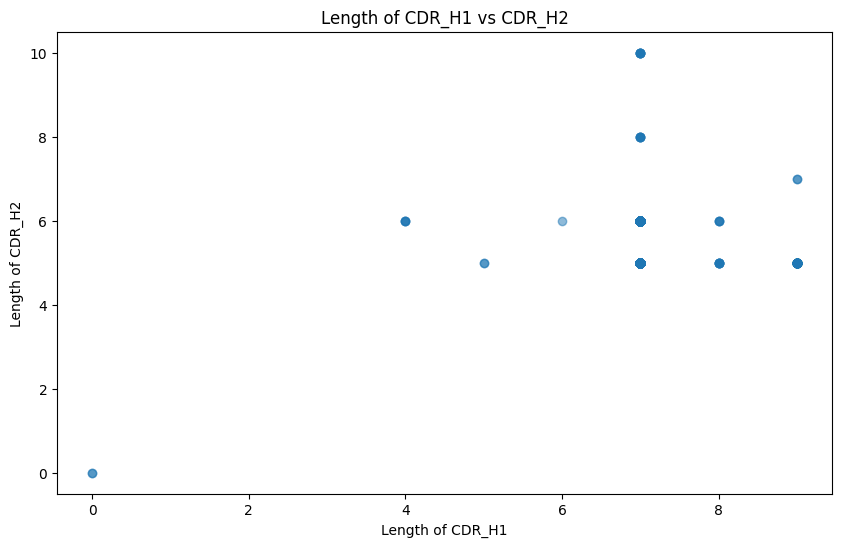

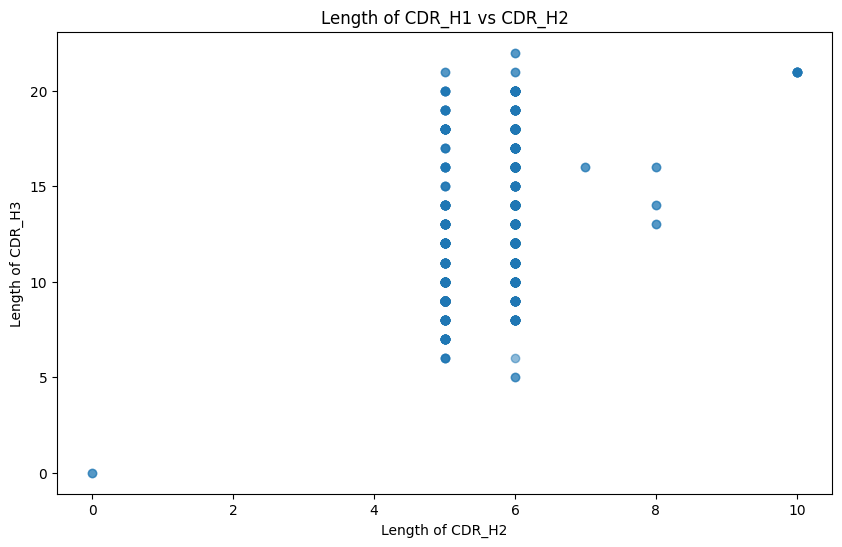

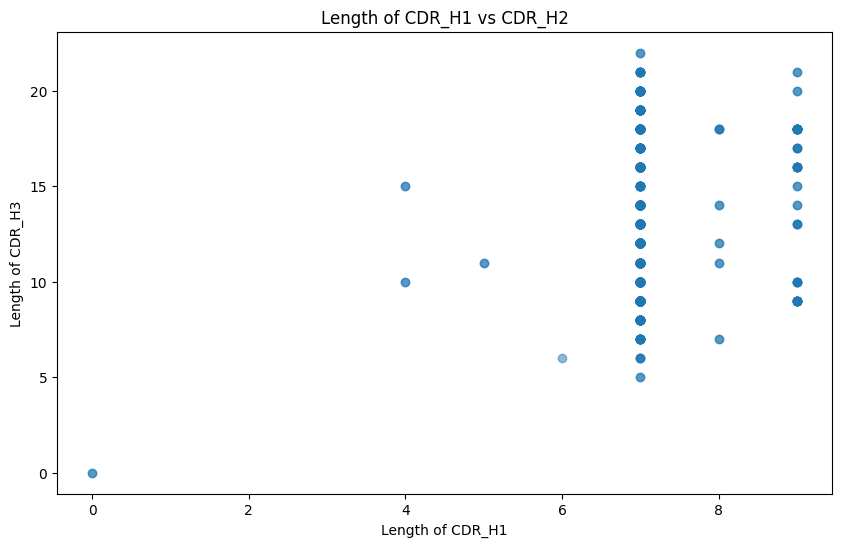

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(data['len_H1'], data['len_H2'], alpha=0.5)
plt.title('Length of CDR_H1 vs CDR_H2')
plt.xlabel('Length of CDR_H1')
plt.ylabel('Length of CDR_H2')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data['len_H2'], data['len_H3'], alpha=0.5)
plt.title('Length of CDR_H1 vs CDR_H2')
plt.xlabel('Length of CDR_H2')
plt.ylabel('Length of CDR_H3')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data['len_H1'], data['len_H3'], alpha=0.5)
plt.title('Length of CDR_H1 vs CDR_H2')
plt.xlabel('Length of CDR_H1')
plt.ylabel('Length of CDR_H3')
plt.show()

In [33]:
data[['len_H1', 'len_H2', 'len_H3']]

,len_H1,len_H2,len_H3
0,7,6,16
1,9,5,9
2,7,6,21
3,7,6,12
4,7,6,12
...,...,...,...
754,7,6,18
755,7,5,9
756,7,6,12
757,7,6,14


<Axes: >

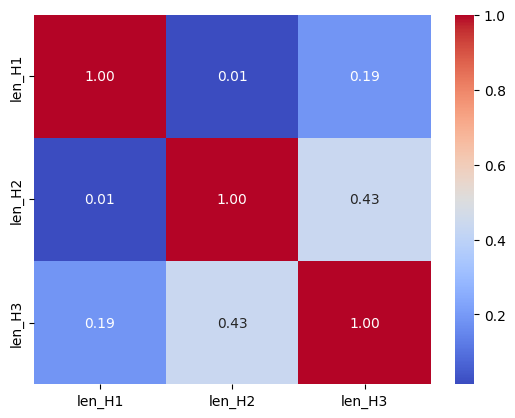

In [37]:
corr = data[['len_H1', 'len_H2', 'len_H3']].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

# human CDRs 

In [15]:
data = pd.read_csv('human_cdr_seq.tsv', sep='\t')

In [16]:
data

,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_mean_hydrophobicity,CDR_H1_mean_charge,CDR_H1_mean_polarity,CDR_H1_mean_mass,CDR_H2_mean_hydrophobicity,...,CDR_H3_count_F,CDR_H3_count_P,CDR_H3_count_S,CDR_H3_count_T,CDR_H3_count_W,CDR_H3_count_Y,CDR_H3_count_V,cdr_h1_length,cdr_h2_length,cdr_h3_length
0,8rmx,E,RFVGTLDV,FWDDD,GFSLDTSGV,4.666667e-01,-0.111111,8.222222,114.005556,-1.720000,...,1.0,0.0,0.0,1.0,0.0,0.0,2.0,9,5,8
1,8rmy,E,RFVGTLDV,FWDDD,GFSLDTSGV,4.666667e-01,-0.111111,8.222222,114.005556,-1.720000,...,1.0,0.0,0.0,1.0,0.0,0.0,2.0,9,5,8
2,9avo,B,GYGWALDY,YPYYGS,GFNVSYY,-4.285714e-02,0.000000,7.614286,136.714286,-1.116667,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,7,6,8
3,9awe,B,GYGWALDY,YPYYGS,GFNVSYY,-4.285714e-02,0.000000,7.614286,136.714286,-1.116667,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,7,6,8
4,9dq3,H,TGWLGPFDY,SYDGRH,GFTFSKY,-2.142857e-01,0.142857,7.814286,136.720000,-2.283333,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,7,6,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,5o4g,B,PPVYYDSAWFAY,YPGSGY,GYTFTAY,2.857143e-02,0.000000,7.414286,132.852857,-0.966667,...,1.0,2.0,1.0,0.0,1.0,3.0,1.0,7,6,12
375,7rp3,H,GSSSWYDLGPFDY,YHSGS,GGSISSSN,-3.750000e-01,0.000000,8.950000,104.223750,-1.300000,...,1.0,1.0,3.0,0.0,1.0,2.0,0.0,8,5,13
376,3q1s,H,VAIGVSGFLNYYYYMDV,IYGGT,GGSMINY,-3.172066e-17,0.000000,7.985714,121.274286,0.340000,...,1.0,0.0,1.0,0.0,0.0,4.0,3.0,7,5,17
377,4zfg,H,FVFFLPYAMDY,TPAGGY,GFTISDY,8.571429e-02,-0.142857,8.057143,129.990000,-0.433333,...,3.0,1.0,0.0,0.0,0.0,2.0,1.0,7,6,11


In [27]:
for i in range(1,4):
    data[f'len_H{i}'] = data[f'CDR_H{i}'].apply(lambda x: len(x) if isinstance(x, str) else 0)

In [28]:
data

,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_mean_hydrophobicity,CDR_H1_mean_charge,CDR_H1_mean_polarity,CDR_H1_mean_mass,CDR_H2_mean_hydrophobicity,...,CDR_H3_count_T,CDR_H3_count_W,CDR_H3_count_Y,CDR_H3_count_V,cdr_h1_length,cdr_h2_length,cdr_h3_length,len_H1,len_H2,len_H3
0,8rmx,E,RFVGTLDV,FWDDD,GFSLDTSGV,4.666667e-01,-0.111111,8.222222,114.005556,-1.720000,...,1.0,0.0,0.0,2.0,9,5,8,9,5,8
1,8rmy,E,RFVGTLDV,FWDDD,GFSLDTSGV,4.666667e-01,-0.111111,8.222222,114.005556,-1.720000,...,1.0,0.0,0.0,2.0,9,5,8,9,5,8
2,9avo,B,GYGWALDY,YPYYGS,GFNVSYY,-4.285714e-02,0.000000,7.614286,136.714286,-1.116667,...,0.0,1.0,2.0,0.0,7,6,8,7,6,8
3,9awe,B,GYGWALDY,YPYYGS,GFNVSYY,-4.285714e-02,0.000000,7.614286,136.714286,-1.116667,...,0.0,1.0,2.0,0.0,7,6,8,7,6,8
4,9dq3,H,TGWLGPFDY,SYDGRH,GFTFSKY,-2.142857e-01,0.142857,7.814286,136.720000,-2.283333,...,1.0,1.0,1.0,0.0,7,6,9,7,6,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,5o4g,B,PPVYYDSAWFAY,YPGSGY,GYTFTAY,2.857143e-02,0.000000,7.414286,132.852857,-0.966667,...,0.0,1.0,3.0,1.0,7,6,12,7,6,12
375,7rp3,H,GSSSWYDLGPFDY,YHSGS,GGSISSSN,-3.750000e-01,0.000000,8.950000,104.223750,-1.300000,...,0.0,1.0,2.0,0.0,8,5,13,8,5,13
376,3q1s,H,VAIGVSGFLNYYYYMDV,IYGGT,GGSMINY,-3.172066e-17,0.000000,7.985714,121.274286,0.340000,...,0.0,0.0,4.0,3.0,7,5,17,7,5,17
377,4zfg,H,FVFFLPYAMDY,TPAGGY,GFTISDY,8.571429e-02,-0.142857,8.057143,129.990000,-0.433333,...,0.0,0.0,2.0,1.0,7,6,11,7,6,11


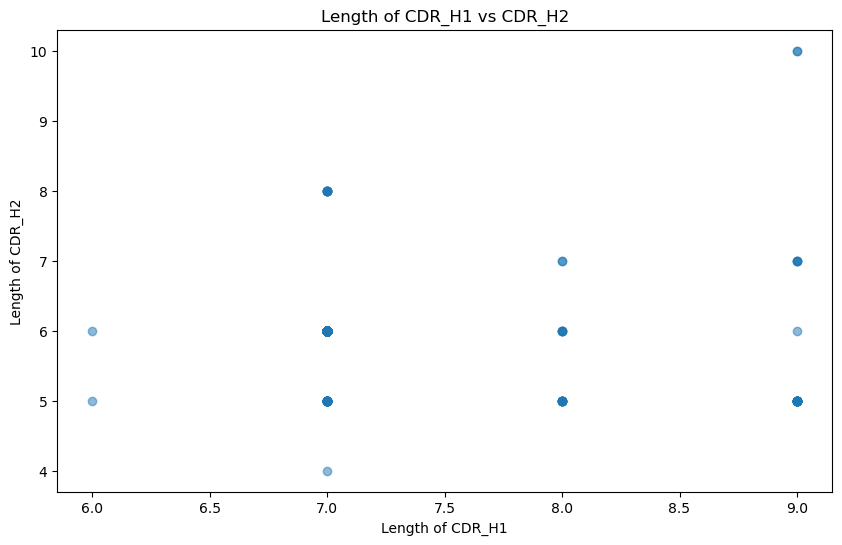

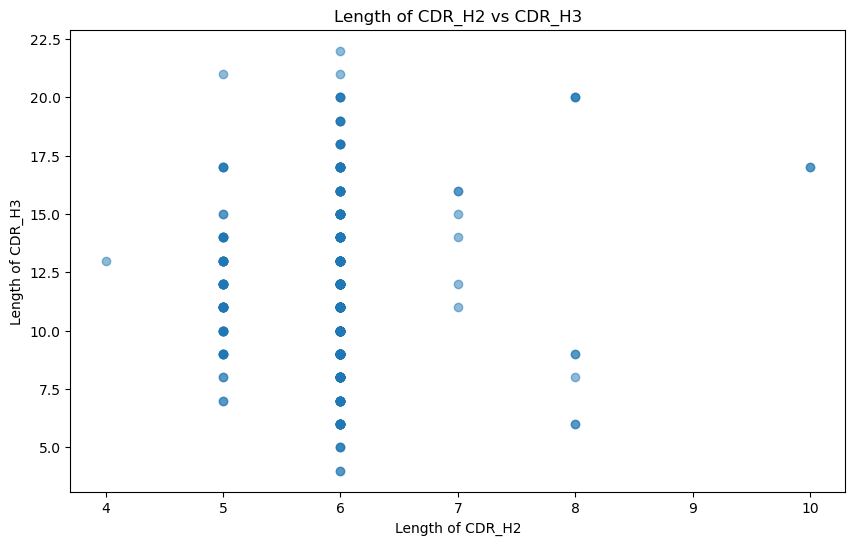

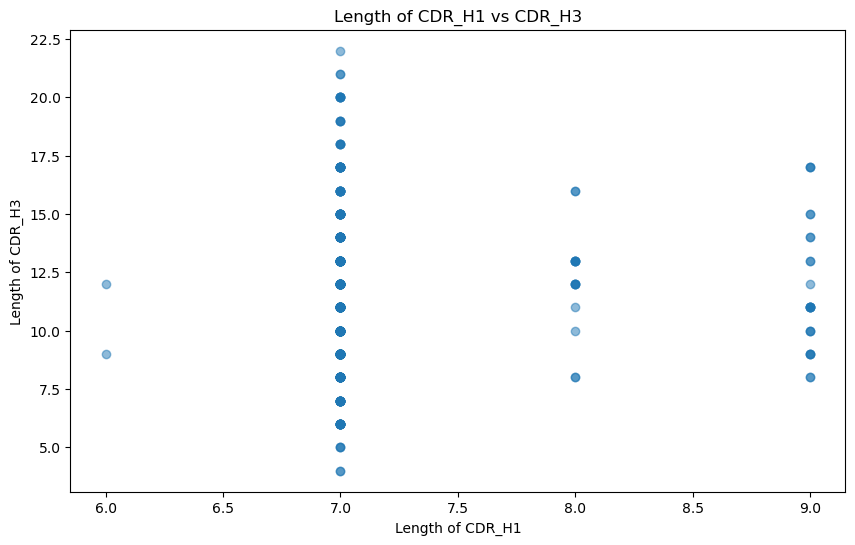

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(data['len_H1'], data['len_H2'], alpha=0.5)
plt.title('Length of CDR_H1 vs CDR_H2')
plt.xlabel('Length of CDR_H1')
plt.ylabel('Length of CDR_H2')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data['len_H2'], data['len_H3'], alpha=0.5)
plt.title('Length of CDR_H2 vs CDR_H3')
plt.xlabel('Length of CDR_H2')
plt.ylabel('Length of CDR_H3')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data['len_H1'], data['len_H3'], alpha=0.5)
plt.title('Length of CDR_H1 vs CDR_H3')
plt.xlabel('Length of CDR_H1')
plt.ylabel('Length of CDR_H3')
plt.show()

In [10]:
data[['len_H1', 'len_H2', 'len_H3']]

,len_H1,len_H2,len_H3
0,9,5,8
1,9,5,8
2,7,6,8
3,7,6,8
4,7,6,9
...,...,...,...
376,7,6,12
377,8,5,13
378,7,5,17
379,7,6,11


<Axes: >

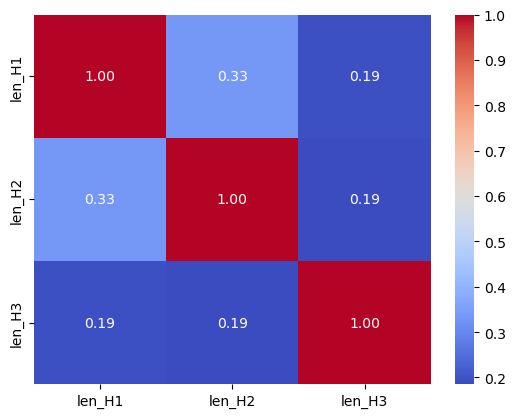

In [16]:
corr = data[['len_H1', 'len_H2', 'len_H3']].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

In [29]:
correlation = data['len_H1'].corr(data['len_H2'])
print("Correlation between len_H2 et len_H1 :", correlation)

Correlation between len_H2 et len_H1 : -0.12514587039915173


# influenza CDR